In [4]:
import math
import random


def objective_function(x):
    return x ** 2 - 6 * x + 13


def get_float_input(prompt, default):
    raw = input(f"{prompt} [default = {default}]: ").strip()
    if raw == "":
        return default
    try:
        return float(raw)
    except ValueError:
        return default


def get_random_numbers_input():
    raw = input("Enter fixed random numbers for acceptance test, comma-separated (blank = use random): ").strip()
    if raw == "":
        return None
    return [float(v) for v in raw.split(",")]


def simulated_annealing(x0, initial_temp, min_temp, alpha, fixed_randoms=None):
    current_x = x0
    current_value = objective_function(current_x)
    best_x, best_value = current_x, current_value

    temperature = initial_temp
    iteration = 0
    rand_index = 0

    history_records = []  # Initialize history_records

    print(f"{'Iter':<6}{'T':<8}{'x':<6}{'x_new':<8}{'f(x)':<8}{'f(x_new)':<10}{'Delta_f':<10}{'P':<10}{'r':<10}{'Result':<10}")

    while temperature > min_temp:
        iteration += 1
        step = random.choice([-1, 1])
        new_x = current_x + step
        new_value = objective_function(new_x)
        delta_f = new_value - current_value

        if delta_f <= 0:
            p = 1.0
            r = None
            accept = True
        else:
            p = math.exp(-delta_f / temperature)
            if fixed_randoms is not None and rand_index < len(fixed_randoms):
                r = fixed_randoms[rand_index]
                rand_index += 1
            else:
                r = random.random()
            accept = r <= p

        accept_status = 'Accept' if accept else 'Reject'
        # Record history for plotting: (iteration, current_x, temperature, new_x, current_value, new_value, delta_f, p, r, accept_status)
        history_records.append((iteration, current_x, temperature, new_x, current_value, new_value, delta_f, p, r, accept_status))

        print(f"{iteration:<6}{temperature:<8.3f}{current_x:<6}{new_x:<8}{current_value:<8}{new_value:<10}{delta_f:<10}{p:<10.4f}{'' if r is None else round(r,2):<10}{accept_status:<10}")

        if accept:
            current_x, current_value = new_x, new_value
            if current_value < best_value:
                best_x, best_value = current_x, current_value

        temperature *= alpha

    return best_x, best_value, history_records  # Return history_records as well


def main():
    x0 = get_float_input("initial_x", 1)
    initial_temp = get_float_input("initial_temperature", 10)
    min_temp = get_float_input("min_temperature", 1)
    alpha = get_float_input("alpha", 0.5)
    fixed_randoms = get_random_numbers_input()

    random.seed()

    best_x, best_value, history_records = simulated_annealing(x0, initial_temp, min_temp, alpha, fixed_randoms)

    print(f"\nbest_x = {best_x}")
    print(f"best_f(x) = {best_value}")


if __name__ == "__main__":
    main()

initial_x [default = 1]: 1
initial_temperature [default = 10]: 
min_temperature [default = 1]: 
alpha [default = 0.5]: 
Enter fixed random numbers for acceptance test, comma-separated (blank = use random): 
Iter  T       x     x_new   f(x)    f(x_new)  Delta_f   P         r         Result    
1     10.000  1.0   2.0     8.0     5.0       -3.0      1.0000              Accept    
2     5.000   2.0   3.0     5.0     4.0       -1.0      1.0000              Accept    
3     2.500   3.0   2.0     4.0     5.0       1.0       0.6703    0.53      Accept    
4     1.250   2.0   1.0     5.0     8.0       3.0       0.0907    0.77      Reject    

best_x = 3.0
best_f(x) = 4.0


In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_sa(history, x0, xf_min=-2, xf_max=8):
    xs = [h[1] for h in history]
    fs = [h[4] for h in history]

    x_curve = np.linspace(xf_min, xf_max, 200)
    y_curve = objective_function(x_curve)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].plot(x_curve, y_curve, label="f(x) = x^2 - 6x + 13")
    ax[0].plot(xs, fs, 'ro--', label="SA path")
    ax[0].scatter([x0], [objective_function(x0)], c='green', s=100, label="Start")
    ax[0].scatter([xs[-1]], [fs[-1]], c='black', s=100, label="End")
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("f(x)")
    ax[0].legend()
    ax[0].set_title("Search Path on Objective Function")

    ax[1].plot(range(1, len(fs) + 1), fs, 'b-o')
    ax[1].set_xlabel("Iteration")
    ax[1].set_ylabel("f(x)")
    ax[1].set_title("Convergence over Iterations")

    plt.tight_layout()
    plt.savefig("sa_visualization.png")
    plt.show()

Iter  T       x     x_new   f(x)    f(x_new)  Delta_f   P         r         Result    
1     10.000  1     0       8       13        5         0.6065    0.2       Accept    
2     8.000   0     -1      13      20        7         0.4169    0.29      Accept    
3     6.400   -1    -2      20      29        9         0.2451    0.27      Reject    
4     5.120   -1    -2      20      29        9         0.1724    0.84      Reject    
5     4.096   -1    0       20      13        -7        1.0000              Accept    
6     3.277   0     -1      13      20        7         0.1181    0.41      Reject    
7     2.621   0     -1      13      20        7         0.0692    0.33      Reject    
8     2.097   0     1       13      8         -5        1.0000              Accept    
9     1.678   1     2       8       5         -3        1.0000              Accept    
10    1.342   2     3       5       4         -1        1.0000              Accept    
11    1.074   3     2       4       5      

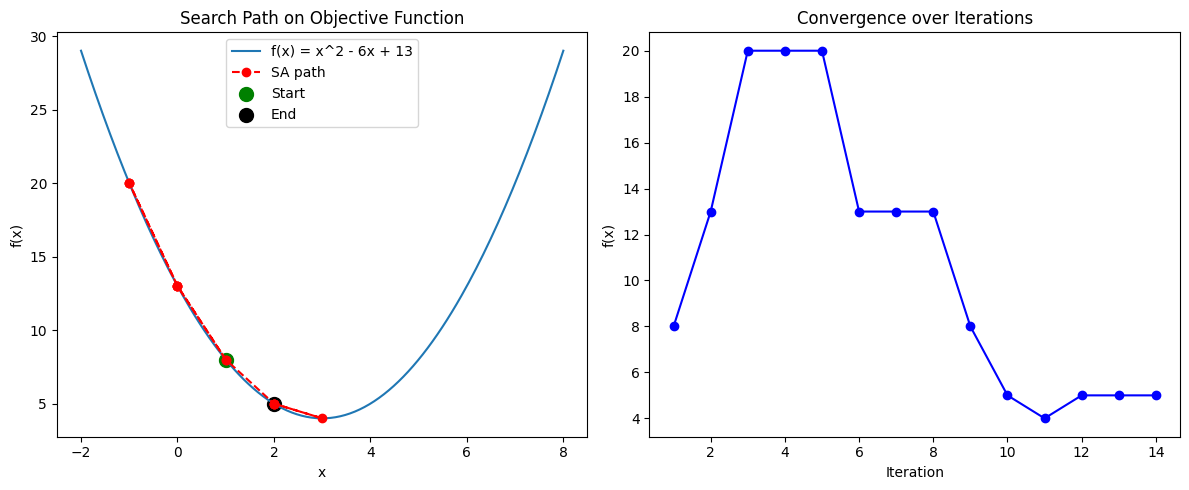


Sample Plot Simulation Results:
Best x found: 3
Best f(x) found: 4


In [7]:

x0_plot = 1
initial_temp_plot = 10
min_temp_plot = 0.5
alpha_plot = 0.8

best_x_plot, best_value_plot, history_plot = simulated_annealing(x0_plot, initial_temp_plot, min_temp_plot, alpha_plot)

plot_sa(history_plot, x0_plot)

print(f"\nSample Plot Simulation Results:\nBest x found: {best_x_plot}\nBest f(x) found: {best_value_plot}")